In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def distribucion_grado(grados):
    k, conteos = np.unique(grados, return_counts=True)
    pk = conteos / len(grados)
    return k, pk

## Ejercicio 1. Comparación de distribuciones

Genera dos conjuntos de datos de tamaño grande (por ejemplo,  N=10^4):

Uno que siga una distribución de Poisson.
Otro que siga una distribución de ley de potencia con exponente  γ.

Calcula la distribución de grado  
p_k en ambos casos.

Tareas:

Grafica ambas distribuciones en escala lineal.

Grafícalas en escala log-log.

Compara visualmente ambas gráficas.

In [3]:
#Creo las distribuciones de grados
np.random.seed(42)
poisson = np.random.poisson(lam =5, size =10**4)
potencias = np.random.zipf(4, 10**4)


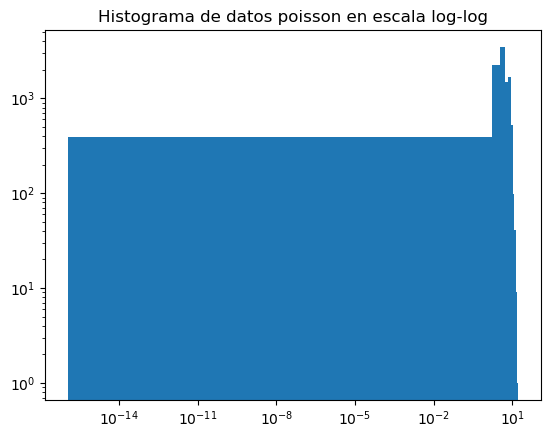

In [4]:
#Grafico en escala log-log
plt.figure()
plt.hist(poisson)
plt.title('Histograma de datos poisson en escala log-log')
plt.xscale('log')
plt.yscale('log')
plt.show()

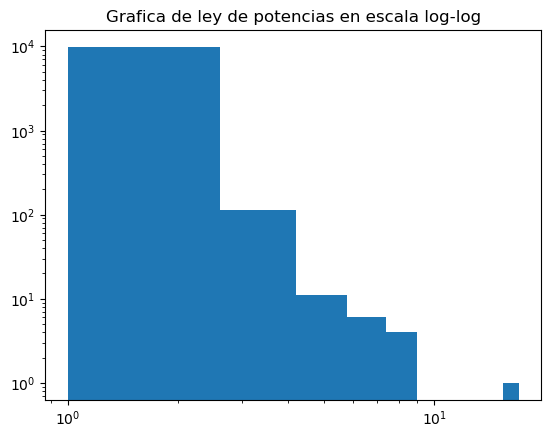

In [5]:
#Grafico en escala log-log
plt.figure()
plt.hist(potencias)
plt.title('Grafica de ley de potencias en escala log-log')
plt.xscale('log')
plt.yscale('log')
plt.show()

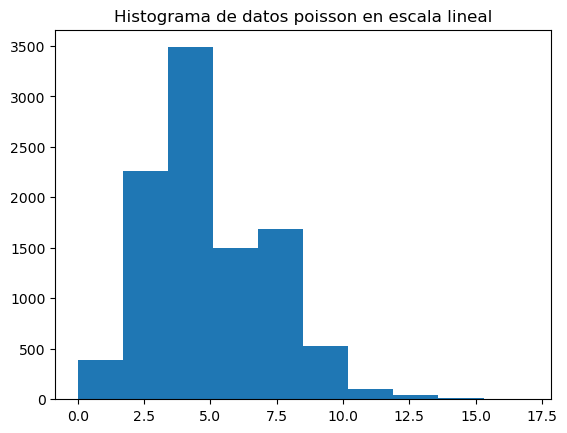

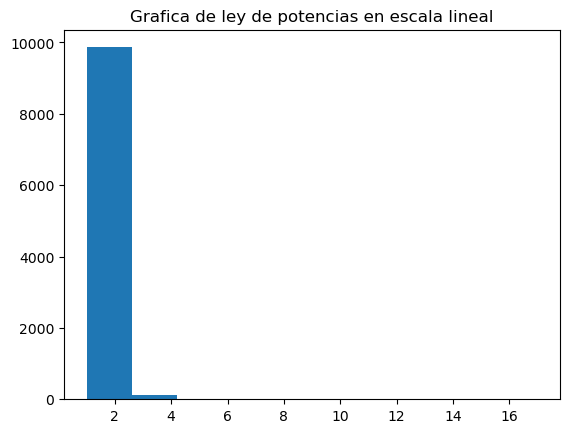

In [6]:
#Grafico en escala log-log
#Grafico en escala log-log
plt.figure()
plt.hist(poisson)
plt.title('Histograma de datos poisson en escala lineal')
plt.show()

plt.figure()
plt.hist(potencias)
plt.title('Grafica de ley de potencias en escala lineal')
plt.show()

Preguntas:

¿Qué diferencias observas entre ambas distribuciones?
sin la escala log log solamente que la de distribucion poisson decae mas lento que la de la ley de potencias


¿En cuál aparecen nodos con grados muy grandes (hubs)?
En la que sigue la ley de potencias

## Ejercicio 2
Usando una muestra con distribución de ley de potencia:

Tareas:

Grafica la distribución de grado en escala lineal.
Grafícala en escala log-log.
Preguntas:

¿Qué información se pierde en la escala lineal?
Se pierda en la grafica muchos nodos que son hubs

¿Por qué la gráfica log-log permite observar mejor la cola de la distribución?
si ya que en cierta manera se puede llegar a observar si exiten o no hubs

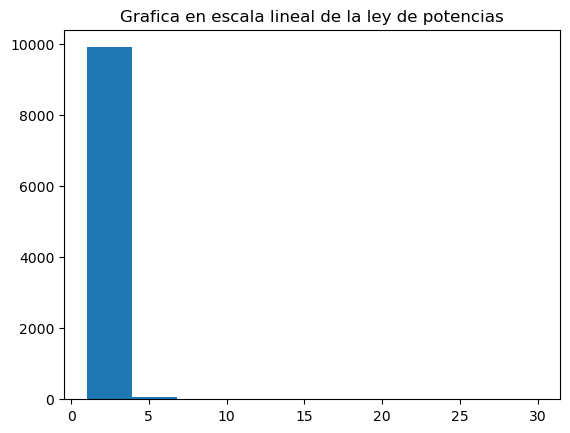

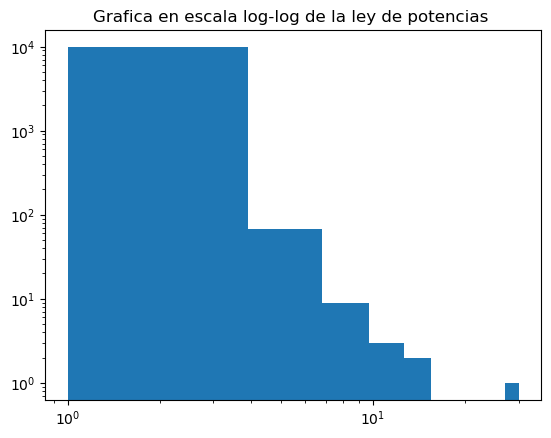

In [7]:
np.random.seed(23)
potencias = np.random.zipf(4, 10**4)
plt.figure()
plt.hist(potencias)
plt.title("Grafica en escala lineal de la ley de potencias")
## 3, 7,5 

plt.show()


plt.figure()
plt.hist(potencias)
plt.xscale('log')
plt.yscale('log')
plt.title('Grafica en escala log-log de la ley de potencias ')
plt.show()

## Ejercicio 3. Linear binning vs log-binning

Genera un conjunto de grados con distribución de ley de potencia.

Tareas:

Construye un histograma usando bins lineales.


Construye un histograma usando bins logarítmicos.

Grafica ambos en escala log-log.
Preguntas:

¿Aparece una meseta en la cola con bins lineales?

no en la cola sino mas bien al principio de la grafica es donde se nota mas bien una meseta


¿Qué cambia al usar bins logarítmicos?
Se puede apreciar de mejor forma que estos datos siguen la ley de pontencias

¿Cuál método representa mejor la distribución?
la que tiene bins logaritmicos

In [8]:
np.random.seed(989)
data = np.random.lognormal(mean=1, sigma=1, size=10000)
linear_bins = np.linspace(data.min(), data.max(), 30)
log_bins = np.geomspace(data.min(), data.max(), 10)

potencias = np.random.zipf(4, 10**4)

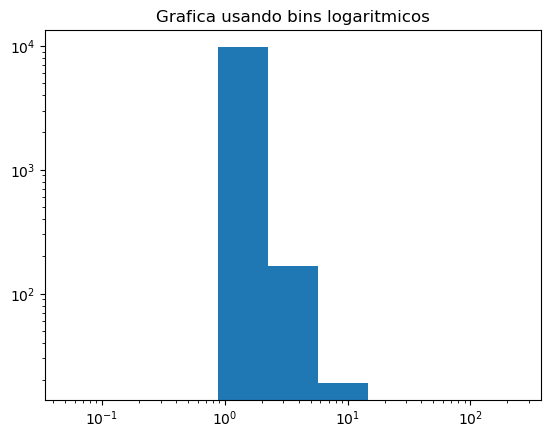

In [9]:
plt.figure()
plt.hist(potencias,bins = log_bins)
plt.title('Grafica usando bins logaritmicos')
plt.xscale('log')
plt.yscale('log')
plt.show()

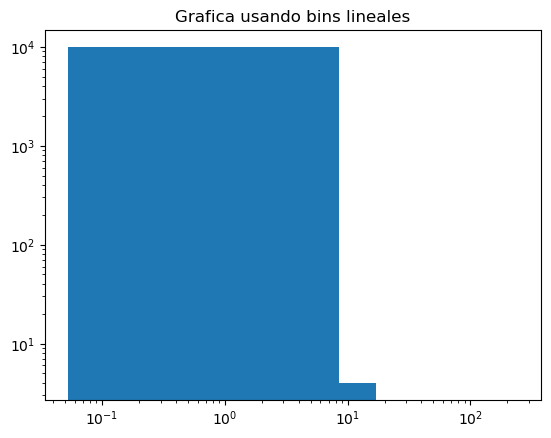

In [10]:
plt.figure()
plt.hist(potencias,bins = linear_bins)
plt.title('Grafica usando bins lineales')
plt.xscale('log')
plt.yscale('log')
plt.show()

# Ejercicio 4. Distribución acumulada

Dada una muestra de grados con ley de potencia:

Tareas:

Calcula la distribución acumulada complementaria:
P(k)=P(K≥k)
 
Grafícala en escala log-log.
Preguntas:

¿Qué ventaja tiene la distribución acumulada respecto al histograma?
Se puede apreciar como se acumula los grados de los nodos

¿Qué sucede con el ruido en la cola?
Empieza a disminuir

In [11]:
np.random.seed(10000)
grados  = np.random.zipf(2.5, 10**4)

k, pk = distribucion_grado(grados)

cdf = np.cumsum(pk)


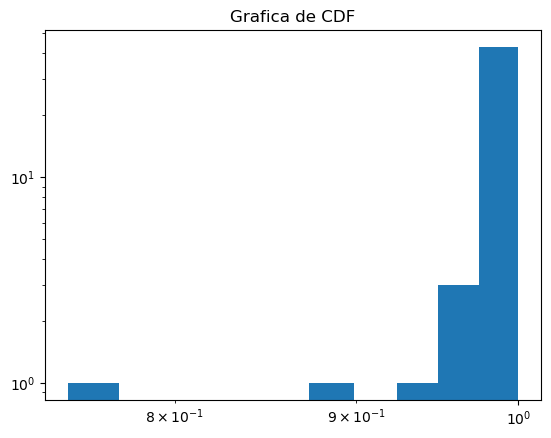

In [12]:
plt.figure()
plt.hist(cdf)
plt.title('Grafica de CDF')
plt.xscale('log')
plt.yscale('log')
plt.show()

## Ejercicio 5. El papel del exponente  γ
 

Genera distribuciones de ley de potencia con distintos valores de  γ, por ejemplo:

γ = 2.1,2.5,3.0,4.0
 

Tareas:

Grafica todas las distribuciones en escala log-log.

Preguntas:

¿Cómo cambia la forma de la distribución al variar  γ? Se puede decir que pasa de ser una curva que decae suavemente a una linea empinada.

¿Para qué valores aparecen hubs más grandes? para valores mayores a 2.1

¿Cuándo la distribución empieza a parecerse a una red aleatoria?cuando el alpha es menor a 2.5

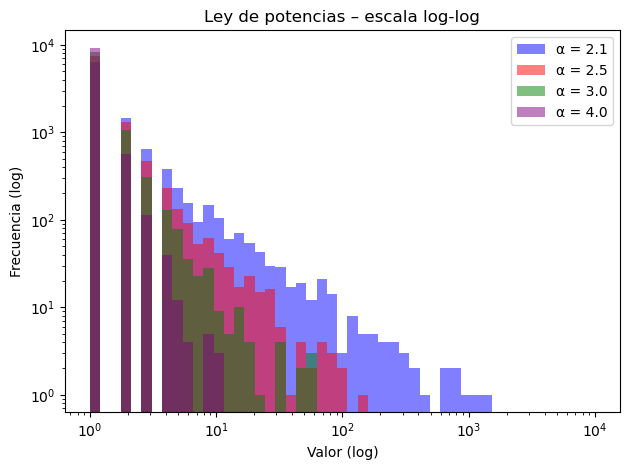

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(23)
potencias  = np.random.zipf(2.1, 10**4)
potencias2 = np.random.zipf(2.5, 10**4)
potencias3 = np.random.zipf(3,   10**4)
potencias4 = np.random.zipf(4,   10**4)

bins = np.logspace(0, 4, 50)  # bins compartidos para ambas gráficas

colores  = ['blue', 'red', 'green', 'purple']
etiquetas = ['α = 2.1', 'α = 2.5', 'α = 3.0', 'α = 4.0']
datos    = [potencias, potencias2, potencias3, potencias4]


plt.figure()
for d, c, e in zip(datos, colores, etiquetas):
    plt.hist(d, bins=bins, alpha=0.5, color=c, label=e)

plt.xscale('log')
plt.yscale('log')
plt.title("Ley de potencias – escala log-log")
plt.xlabel("Valor (log)")
plt.ylabel("Frecuencia (log)")
plt.legend()
plt.tight_layout()
plt.show()

## Ejercicio 6. Tamaño de la red y hubs

Para distintos tamaños de red:

N=10^2,10^3,10^4,10^5
 

genera muestras con distribución de ley de potencia.

Tareas:

Para cada  N, calcula el grado máximo  kmax.

Grafica  kmax como función de  N.

Preguntas:

¿Cómo crece el hub más grande con el tamaño de la red?
de forma como logaritmica

¿Es el crecimiento rápido o lento?
es lento

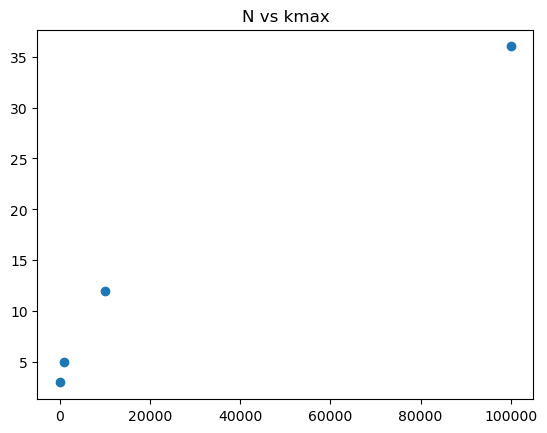

In [14]:
N = [10**2, 10**3, 10**4, 10**5]
gamma = 4
kmax_arr = []
for n in N:
    dist = np.random.zipf(gamma,n)
    kmax = max(dist)
    kmax_arr.append(kmax)

plt.figure()
plt.title('N vs kmax')
plt.scatter(N,kmax_arr)
plt.show()

## Ejercicio 7. Redes aleatorias vs redes libres de escala

Genera dos redes con el mismo número de nodos:

Una red de Erdős–Rényi.

Una red de Barabási–Albert, esto simula la red libre de escala.

Tareas:


Calcula la distribución de grado en ambas redes.

Grafícalas en escala log-log.

Calcula:

grado promedio

grado máximo

Preguntas:

¿En cuál red aparecen hubs? En la de Barabasi-Albert

¿En cuál red los grados son más homogéneos? En la de Erdos-Renyi


In [15]:
n=100
E = nx.erdos_renyi_graph(n, 0.02)
m_total = nx.number_of_edges(E)
m = max(1, round(m_total / n)) 
B = nx.barabasi_albert_graph(100,m)
degE=list(dict(nx.degree(E)).values())
degB =list(dict(nx.degree(B)).values())

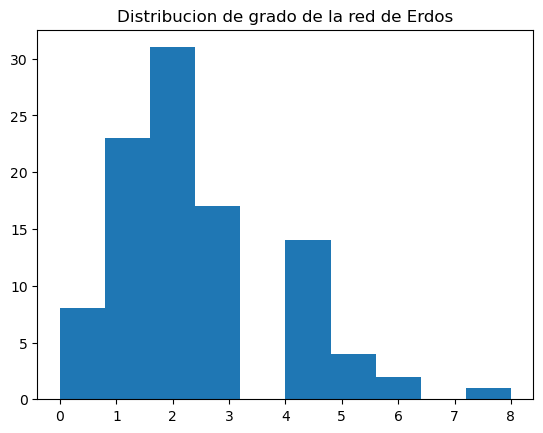

In [16]:
plt.figure()
plt.title('Distribucion de grado de la red de Erdos')
plt.hist(degE)
plt.show()

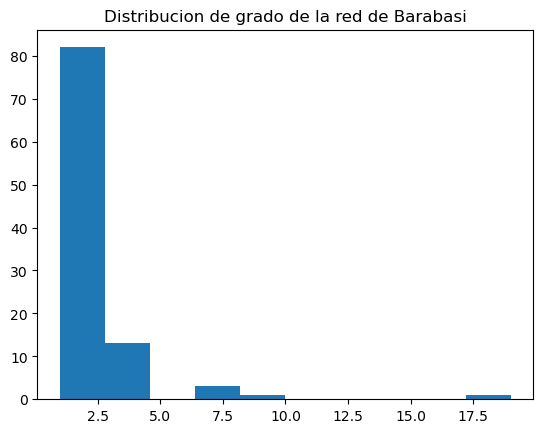

In [17]:
plt.figure()
plt.title('Distribucion de grado de la red de Barabasi')
plt.hist(degB)
plt.show()

Ejercicio 8. Distancias en redes

Usando las redes del ejercicio anterior:

Tareas:

Calcula la distancia promedio entre nodos (en la componente gigante si es necesario).
Preguntas:

¿Cuál red tiene menor distancia promedio? La de Barabasi

¿Cómo se relaciona esto con la presencia de hubs? Que al tener mas hubs la distancias se van acortando cada ves mas a pesar de tener los mismos nodos


In [18]:
#Calculo la componente mas grande de el grafo de Erdos
largest_cc = max(nx.connected_components(E), key=len)
ccmax= E.subgraph(largest_cc)

#Calculo sus promedios de distancias

print('Distancia promedio del grafo de Erdos:', nx.average_shortest_path_length(ccmax))
print('Distancia promedio del grafo de Barabasi:', nx.average_shortest_path_length(B)) 

Distancia promedio del grafo de Erdos: 5.008739076154806
Distancia promedio del grafo de Barabasi: 4.784040404040404


## Ejercicio 9. Robustez de la red

Considera una red libre de escala.

Tareas:

Elimina nodos de forma aleatoria y mide el tamaño de la componente gigante.

Elimina nodos en orden decreciente de grado (primero los hubs).

Compara ambos casos.

Preguntas:

¿Qué tipo de eliminación afecta más a la red? la eliminación de los hubs

¿Qué nos dice esto sobre la importancia de los hubs? son importantes para que la red sea conexa

In [42]:
n=10000
m=4
n_elim = 100
B = nx.barabasi_albert_graph(n,m)
nodes_rnd = np.random.randint(0,n-1, size = n_elim)

In [43]:
#Hago lo mismo pero ahora para
deg = dict(nx.degree(B))
deg = dict(sorted(deg.items(), key=lambda x: x[1], reverse = True))
nodes_hub = list(deg.keys())[0:n_elim-1]


In [44]:
import copy
print(B)

B1 = copy.deepcopy(B)   
B2 = copy.deepcopy(B)

B1.remove_nodes_from(nodes_rnd)   
B2.remove_nodes_from(nodes_hub)   

Graph with 10000 nodes and 39984 edges


In [45]:
#Hora vemos si estan connectados
print(nx.is_connected(B1))
print(nx.is_connected(B2))

True
False


## Ejercicio 10. Análisis de una red real o simulada

Selecciona una red (real o generada).

Tareas:

Calcula su distribución de grado.

Grafícala en escala log-log.

Decide si:

es exponencialmente acotada, o
tiene cola pesada.

Preguntas:

¿Hay evidencia de hubs?

¿El promedio describe bien a la red?